#### Build a basic Chatbot with langgraph(GRAPH API)


In [1]:
from typing import Annotated
from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages


In [2]:
class State(TypedDict):
    messages:Annotated[list, add_messages]

    

In [3]:
from langchain_groq import ChatGroq
from config import settings

llm = ChatGroq(api_key=settings.GROQ_API_KEY, model=settings.GROQ_MODEL, temperature=0)

In [4]:
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.5.2', 'langchain': '1.3.14'}}, output_version=None, profile={'name': 'Llama 3.3 70B Versatile', 'release_date': '2024-12-06', 'last_updated': '2024-12-06', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 32768, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x0000025116B86120>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000025116B86E40>, model_name='llama-3.3-70b-versatile', temperature=1e-08, model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [5]:
## Node Functionality
def  chatbot(state: State):
    return {"messages":[llm.invoke(state["messages"])]}

In [6]:
graph_builder =StateGraph(State)
## Adding Node
graph_builder.add_node("llmchatbot",chatbot)

## Adding edges
graph_builder.add_edge(START, "llmchatbot")
graph_builder.add_edge("llmchatbot", END)

## compile the graph 
graph = graph_builder.compile()

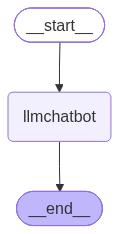

In [7]:
## Visualize the graph 

from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))

except Exception:
    pass

In [8]:
response = graph.invoke({"messages":"Hi"})

In [9]:
response["messages"][-1].content

"It's nice to meet you. Is there something I can help you with or would you like to chat?"

In [10]:
for event in graph.stream({"messages":"Hi How are you?"}):
    for value in event.values():
        print(value["messages"][-1].content)

I'm just a language model, so I don't have feelings or emotions like humans do, but I'm functioning properly and ready to help with any questions or tasks you may have. How about you? How's your day going so far?


##### ChatBot with Tool 

In [11]:
from langchain_tavily import TavilySearch

tool = TavilySearch(max_results = 2)
tool.invoke("what is langgraph")

{'query': 'what is langgraph',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.ibm.com/think/topics/langgraph',
   'title': 'What is LangGraph? - IBM',
   'content': 'LangGraph, created by LangChain, is an open source AI agent framework designed to build, deploy and manage complex generative AI agent workflows. It provides a set of tools and libraries that enable users to create, run and optimize large language models (LLMs) in a scalable and efficient manner. At its core, LangGraph uses the power of graph-based architectures to model and manage the intricate relationships between various components of an AI agent workflow. [...] Agent systems: LangGraph provides a framework for building agent-based systems, which can be used in applications such as robotics, autonomous vehicles or video games.\n\nLLM applications: By using LangGraph’s capabilities, developers can build more sophisticated AI models that learn and improve over time. Norweg

In [12]:
## Custom function

def multiply(a: int , b: int ) -> int:
    """Multiply a and b

    Args:
        a (int): first int 
        b (int): second int 
    
    Returns:
        int: output int
    """
    return a *b

In [13]:
tools = [tool, multiply]


In [14]:
llm_with_tools = llm.bind_tools(tools)

In [15]:
llm_with_tools

_ChatModelBinding(bound=ChatGroq(metadata={'lc_versions': {'langchain-core': '1.5.2', 'langchain': '1.3.14'}}, output_version=None, profile={'name': 'Llama 3.3 70B Versatile', 'release_date': '2024-12-06', 'last_updated': '2024-12-06', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 32768, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x0000025116B86120>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000025116B86E40>, model_name='llama-3.3-70b-versatile', temperature=1e-08, model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'descr

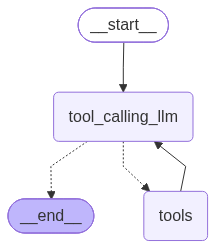

In [16]:
from langgraph.graph import StateGraph
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

builder = StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

## add edges
builder.add_edge(START, "tool_calling_llm",)
builder.add_conditional_edges(
    "tool_calling_llm",
    tools_condition
)

builder.add_edge("tools","tool_calling_llm")

graph = builder.compile()

## Visualize the graph 

from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))

except Exception:
    pass


In [17]:
response = graph.invoke({"messages":"tell me about recent cjp protest" })
response["messages"][-1].content

'The recent CJP protest in India was a mass protest led by the Cockroach Janta Party (CJP) that took place in Delhi. The protest was organized to address issues affecting ordinary people, with a focus on education and its soaring costs. The CJP has announced a nationwide campaign to address these issues, which will include demonstrations and marches in various parts of the country. The protest has been successful in bringing attention to the issues and has led to the resignation of the Education Minister, Dharmendra Pradhan. The CJP has also announced a countrywide drive, "Kya bolti public" (What does the public say), to focus on public issues across India.'

In [18]:
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

tell me about recent cjp protest
================================== Ai Message ==================================
Tool Calls:
  tavily_search (chmq91g18)
 Call ID: chmq91g18
  Args:
    query: CJP protest recent
    search_depth: advanced
    time_range: week
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "CJP protest recent", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.dw.com/en/india-news-cjp-announces-plan-for-nationwide-campaign/live-78274696", "title": "India news: CJP announces plan for nationwide campaign", "content": "After organizing an arguably successful protest, the Cockroach Janta Party (CJP) has decided to act as a pressure group and bring forth issues affecting ordinary people. It has announced a nationwide campaign to address the issues, where education and its s

#### Adding Memory In Agentic Graph


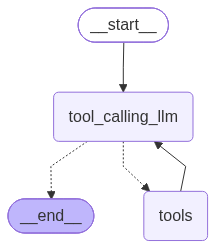

In [19]:
from langgraph.graph import StateGraph
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

builder = StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

## add edges
builder.add_edge(START, "tool_calling_llm",)
builder.add_conditional_edges(
    "tool_calling_llm",
    tools_condition
)

builder.add_edge("tools","tool_calling_llm")

graph = builder.compile(checkpointer=memory)

## Visualize the graph 

from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))

except Exception:
    pass


In [21]:
config = {"configurable":{"thread_id":"1"}}
response = graph.invoke({"messages":"Hi my name is Abhishek "},config = config)
response["messages"][-1].content


"Hello Abhishek! It's nice to meet you. Is there something I can help you with or would you like to chat?"

In [23]:
response = graph.invoke({"messages":"What is my name  "},config = config)
response["messages"][-1].content

'Your name is Abhishek.'